### Generate Predictions using Trained Models

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sys
import os
import time
from pprint import pprint
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
import dask
import xarray as xr
import matplotlib.pyplot as plt
import gcsfs
import json
#fs = gcsfs.GCSFileSystem()

In [3]:
import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data

In [5]:
torch.cuda.is_available()
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

False

In [8]:
base_dir = "/mnt/home/ssa2206/Climsim/experiments"
#base_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "diffusion_hp_search"
run_id = "lr-explore"
lettering = 'abcde'

log_dict_path = os.path.join(base_dir, exp_id, f"{run_id}.json")
with open(log_dict_path, 'r') as file:
    diff_logs = json.load(file)

diff_logs.keys()

dict_keys(['lr-explorea', 'lr-exploreb', 'lr-explorec', 'lr-explored', 'lr-exploree'])

dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_indices', 'train_loss', 'sampled_timesteps'])

In [13]:

mconfigs = {}
tconfigs = {}
dconfigs = {}
diff_models = {}

for i in lettering:
    l = f"{run_id}{i}"
    tconfigs[l] = tru.TrainingConfig(**diff_logs[l]['training_config'])
    mconfigs[l] = tru.ModelConfig(**diff_logs[l]['model_config'])
    dconfigs[l] = tru.DataConfig(**diff_logs[l]['data_config'])
    model_path = os.path.join(base_dir, exp_id, "checkpoints", f"best{l}-ckpt.pt")
    diff_models[l] = tru.load_model_from_ckpt(model_path, mconfigs[l]).to(device)


    

In [15]:
print(diff_models.keys())
print(diff_logs['lr-explorea'].keys())

dict_keys(['lr-explorea', 'lr-exploreb', 'lr-explorec', 'lr-explored', 'lr-exploree'])
dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_indices', 'train_loss', 'sampled_timesteps'])


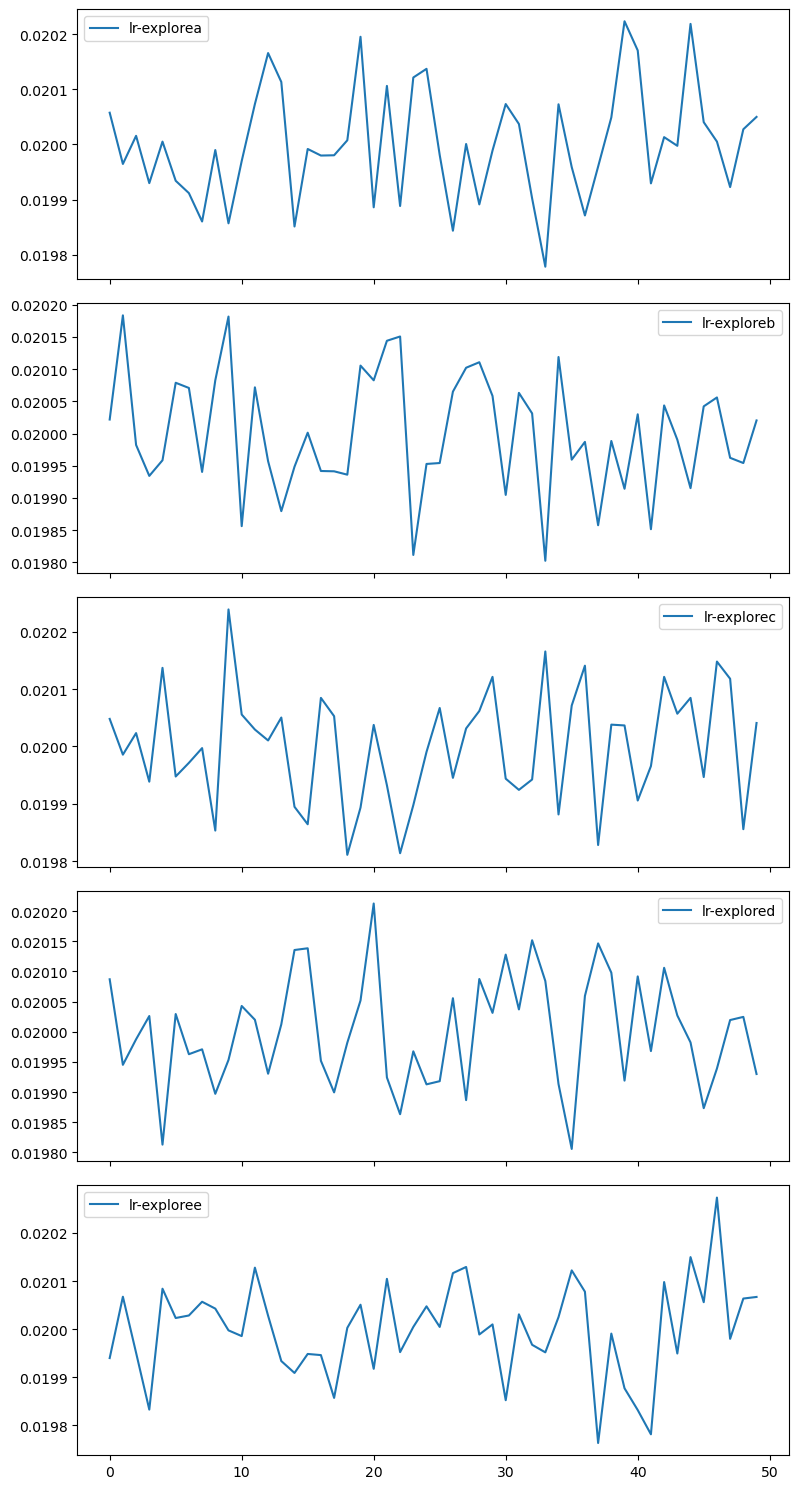

In [19]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 15), sharex=True)

for i, l in enumerate(lettering):
    l = f"{run_id}{l}"
    density = diff_logs[l]['sampled_timesteps'] / np.sum(diff_logs[l]['sampled_timesteps'])
    axes[i].plot(density, label=l)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [21]:
[ds], [indices] = data.load_dataset(dconfigs[f"{run_id}a"])

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [22]:
dataset = ds
train_ds = ds

In [23]:
def plot_loss(diff_logs, dataset=train_ds):
    for key, log in diff_logs.items():
        len(log['train_loss'])
        bs, bli = dconfigs[key].dataloader_params.batch_size, tconfigs[key].batch_logging_interval
        plt.plot(log['losses']['train'], label=f"{key} {tconfigs[key].learning_rate}")
        batches_per_epoch = np.ceil(dataset.data.time.shape[0]  /( bs * bli))
        num_batches, num_epochs = len(log['losses']['train']), tconfigs[key].num_epochs + 1
        plt.xticks(np.arange(0, num_batches, batches_per_epoch), labels=np.arange(1, num_epochs))
    plt.title("Training Loss over time")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

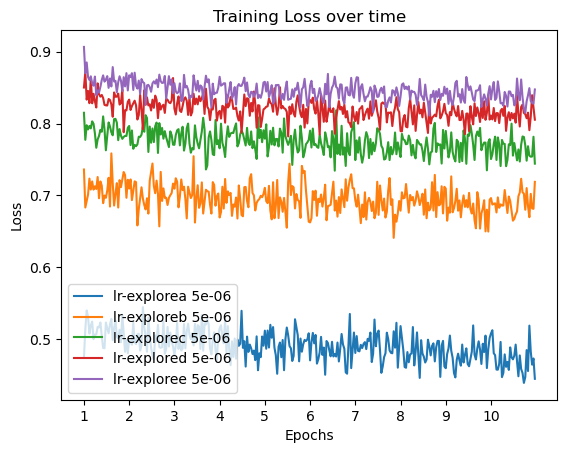

In [24]:
plot_loss(diff_logs)

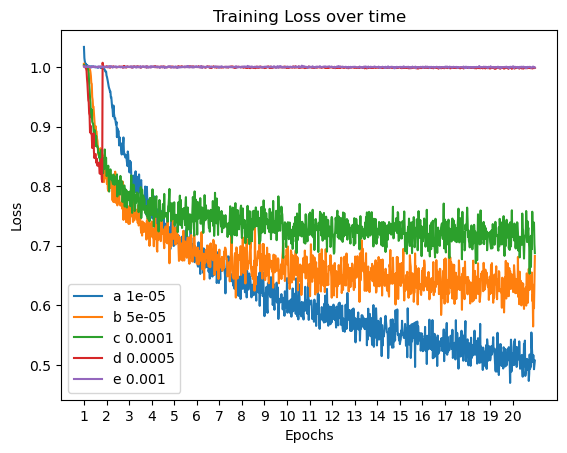

In [14]:
plot_loss(diff_logs)

In [17]:
# generate images
class SampleImages(torch.utils.data.IterableDataset):
    def __init__(self, ddpm, scheduler, steps=100, batch_size=1, eta=1.0):
        self.ddpm = ddpm.to(device)
        self.scheduler = scheduler
        self.set_num_images(batch_size)
        self.eta = 1.0
        # generator: Optional[Union[torch.Generator, List[torch.Generator]]] = None
        # A [`torch.Generator`](https://pytorch.org/docs/stable/generated/torch.Generator.html) make
        # generation deterministic.
        self.num_inference_steps = steps
        
    def set_num_images(self, batch_size):
        self.batch_size = batch_size
        self.image_shape = (batch_size, self.ddpm.config.in_channels, *self.ddpm.config.sample_size)

    def __iter__(self):
        # generate a batch of images
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        self.scheduler.set_timesteps(self.num_inference_steps)
        while(True): # can generate infinite batches      
            image = torch.randn(self.image_shape ).to(device) # could add generator=generator
            for t in pipeline.progress_bar(self.scheduler.timesteps):
                image = self._denoise(image, t)
            yield image
    
    def _denoise(self, xt, t):
        eps_theta = self.ddpm(xt, t).sample
        x_prev = self.scheduler.step(eps_theta, t, xt, eta=self.eta)
        return(x_prev.prev_sample)
        
    def encode(self, sample, t):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = self.scheduler.add_noise(sample, eps, torch.LongTensor([t])) # noisy image
        return(xt, eps)
    
    def decode(self, xt, T, stride=-1, track_history=True):
        if track_history:
            history={}
            history[T-stride] = xt
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        for t in pipeline.progress_bar(range(T, -1, stride)): # pipe.scheduler.timesteps[-T//stride-1:]
            xt = self._denoise(xt, t)
            if track_history:
                history[t] = xt.detach().cpu()
        if track_history:
            return(history)
        return(xt)

## Looking at trained model weights

In [18]:
#trainer = tru.setup_trainer(exp_id, run_id, tconfig, mconfig, dconfig)
#trainer.dataloaders['train'].dataset.log = False
mconfigs['a'].scheduler_type  = 'ddim'
scheduler = data.load_scheduler(mconfigs['a'])

In [37]:
for letter in 'a':
    print(f"___________\nModel {letter}\n___________")
    model = diff_models[letter]

    for name, param in model.named_parameters():
        print(name, "                 ", torch.mean(param))
    

___________
Model a
___________
conv_in.weight                   tensor(-1.0894e-05, device='cuda:0')
conv_in.bias                   tensor(-0.0012, device='cuda:0')
time_embedding.linear_1.weight                   tensor(-0.0004, device='cuda:0')
time_embedding.linear_1.bias                   tensor(-0.0016, device='cuda:0')
time_embedding.linear_2.weight                   tensor(2.1225e-05, device='cuda:0')
time_embedding.linear_2.bias                   tensor(-0.0004, device='cuda:0')
down_blocks.0.resnets.0.norm1.weight                   tensor(0.9834, device='cuda:0')
down_blocks.0.resnets.0.norm1.bias                   tensor(0.0264, device='cuda:0')
down_blocks.0.resnets.0.conv1.weight                   tensor(-0.0004, device='cuda:0')
down_blocks.0.resnets.0.conv1.bias                   tensor(-0.0015, device='cuda:0')
down_blocks.0.resnets.0.time_emb_proj.weight                   tensor(-6.8368e-05, device='cuda:0')
down_blocks.0.resnets.0.time_emb_proj.bias                   

In [6]:
ckpt = os.path.join(base_dir, exp_id, "checkpoints", "lr-searcha-ckpt.pt")
ckpt

'/mnt/home/ssa2206/Climsim/experiments/diffusion-hp-search/checkpoints/lr-searcha-ckpt.pt'

In [7]:

REF_BATCH_SIZE = 128
dataset_type = "xbatch"
in_notebook = False

def setup_run(num_models, exp_id, base_run_id,
              data_vars='v1', batch_size=128):
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [1.0]
    tconfigs, mconfigs = [], []
    learning_rates = [5e-6, 5e-6, 5e-6, 5e-6, 5e-6]
    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.phases = ['train']
        tconfig.loss_weights = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
        tconfig.max_T_sample = 100
        tconfig.clip_gradients = True
        tconfig.batch_logging_interval = 50
        
        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels

        scheduler = tru.SchedulerParams()
        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_num_layers = len(mconfig.bl_hidden_dims)
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

exp_id = "diffusion-hp-search"
run_id = "lr-explore"

tconfigs, mconfigs, _ = setup_run(5, exp_id, run_id)

In [8]:
dconfig = tru.my_dconfig("local-vzarr", 'v1', in_notebook=True, dataset_type="xbatch", batch_size=128, use_tendencies = False)
dconfig.train_test_split = [0.001]


In [11]:
bdir = os.path.join(base_dir, exp_id)

In [12]:
trainer = diff.trainers.DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), bdir, rank=0)


ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [77]:
weights = torch.load(ckpt, map_location=trainer.device)

/tmp/ipykernel_417511/386544795.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(ckpt, map_location=trainer.device)


In [87]:
for name, param in trainer.models['lr-searcha'].named_parameters():
    if re.search(r'\.norm\d+\.(weight|bias)', name):
        print(name, "                 ", torch.mean(param).item())
    elif 'time_embedding' in name:
        pass
    elif 'conv' in name:
        pass

    elif re.search(r'\.weight|\.bias', name):
       pass 
    else:
        print("wahuhhh")

down_blocks.0.resnets.0.norm1.weight                   1.0
down_blocks.0.resnets.0.norm1.bias                   0.0
down_blocks.0.resnets.0.norm2.weight                   1.0
down_blocks.0.resnets.0.norm2.bias                   0.0
down_blocks.1.resnets.0.norm1.weight                   1.0
down_blocks.1.resnets.0.norm1.bias                   0.0
down_blocks.1.resnets.0.norm2.weight                   1.0
down_blocks.1.resnets.0.norm2.bias                   0.0
down_blocks.2.resnets.0.norm1.weight                   1.0
down_blocks.2.resnets.0.norm1.bias                   0.0
down_blocks.2.resnets.0.norm2.weight                   1.0
down_blocks.2.resnets.0.norm2.bias                   0.0
up_blocks.0.resnets.0.norm1.weight                   1.0
up_blocks.0.resnets.0.norm1.bias                   0.0
up_blocks.0.resnets.0.norm2.weight                   1.0
up_blocks.0.resnets.0.norm2.bias                   0.0
up_blocks.0.resnets.1.norm1.weight                   1.0
up_blocks.0.resnets.1.n

In [83]:
trainer.models.keys()

dict_keys(['lr-searcha', 'lr-searchb', 'lr-searchc', 'lr-searchd', 'lr-searche'])

In [112]:
import re
noise_levels = [0.0, 0.5, 1.0, 1.0, 1.5]

for i, run_id in enumerate(trainer.models.keys()):
    model = trainer.models[run_id]
    model.load_state_dict(weights)
    noise_level = noise_levels[i]

    for name, param in model.named_parameters():
        if not param.requires_grad or re.search(r'\.norm\d+\.(weight|bias)', name):
            continue
        with torch.no_grad():
            std = torch.std(param).item()
            #mean = torch.mean(param).item()
            if 'time_embedding' in name:
                param.add_(0.3 * noise_level * std * torch.randn_like(param))
            elif 'conv' in name:
                param.add_(0.05 * noise_level * std * torch.randn_like(param))
            elif re.search(r'\.weight|\.bias', name):
                param.add_(0.5 * noise_level * std * torch.randn_like(param))
            else:
                print(f"  -> Skipping: {name}")


In [117]:
trainer.run_ids

['lr-searcha', 'lr-searchb', 'lr-searchc', 'lr-searchd', 'lr-searche']

In [116]:
trainer.dirs

{'log_dir': '/mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search',
 'ckpt_dir': '/mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints',
 'output_dir': '/mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/outputs'}

In [60]:
dataset = ds
dataset

## Testing Sample Recreation

In [ ]:
pipeline_generator = SampleImages(diff_models['a'], scheduler)

In [61]:
dataset.data

<xarray.Dataset> Size: 83GB
Dimensions:         (time: 210238, lev: 60, ncol: 384)
Coordinates:
  * time            (time) object 2MB 0001-02-01 00:40:00 ... 0009-01-31 23:4...
  * ncol            (ncol) int64 3kB 0 1 2 3 4 5 6 ... 378 379 380 381 382 383
    lat             (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 40.39
    lon             (ncol) float64 3kB -39.73 -28.47 -39.56 ... 146.7 135.0
Dimensions without coordinates: lev
Data variables:
    state_t         (time, lev, ncol) float64 39GB dask.array<chunksize=(252, 8, 96), meta=np.ndarray>
    state_q0001     (time, lev, ncol) float64 39GB dask.array<chunksize=(252, 8, 96), meta=np.ndarray>
    cam_out_NETSW   (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_FLWDS   (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_PRECSC  (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_PRECC   (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_SOLS    (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_SOLL    (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_SOLSD   (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>
    cam_out_SOLLD   (time, ncol) float64 646MB dask.array<chunksize=(252, 96), meta=np.ndarray>

In [66]:
pipeline_generator.set_num_images(32)
image = next(iter(pipeline_generator))

  0%|          | 0/100 [00:00<?, ?it/s]

In [67]:
type(image), image.dtype, image.shape

(torch.Tensor, torch.float32, torch.Size([32, 128, 16, 24]))

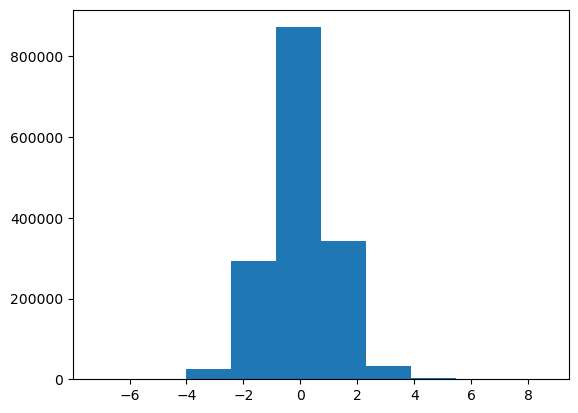

In [72]:
plt.hist(image.detach().cpu().numpy().flatten())
plt.show()

In [77]:
sample = dataset[0]

In [78]:
type(sample), sample.dtype, sample.shape

(torch.Tensor, torch.float32, torch.Size([128, 128, 16, 24]))

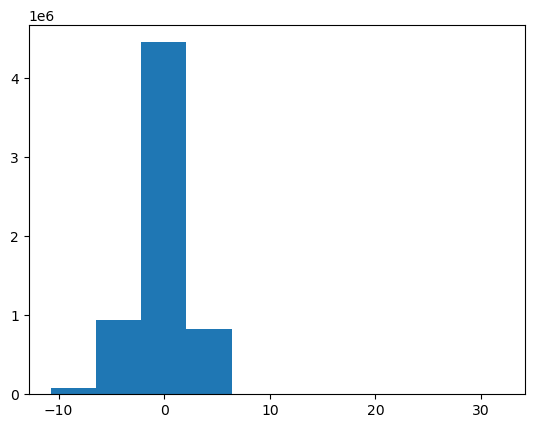

In [79]:
plt.hist(sample.numpy().flatten()) # more variance/ tails 
plt.show()

In [80]:
sample = recreate_sample(sample)

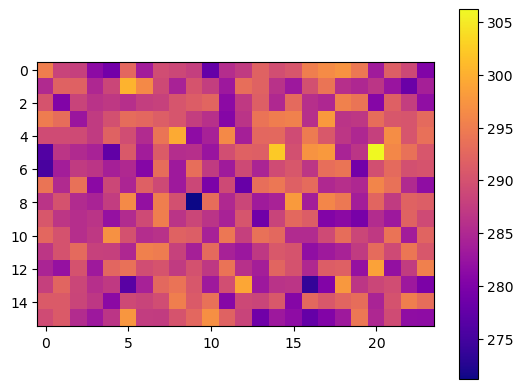

In [82]:
rec_image = recreate_sample(image.detach().cpu())
tmap = rec_image.isel(time=0, mlo=59, ncol=dataset.permute_indices).data
plt.imshow(tmap.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

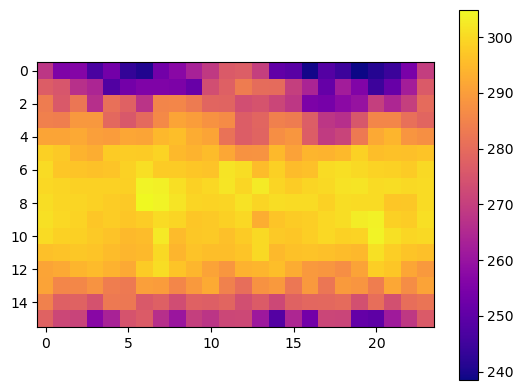

In [83]:
tmap = sample.isel(time=0, mlo=59, ncol=dataset.permute_indices).data
plt.imshow(tmap.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [90]:
og = dataset.data.state_t.isel(time=0, lev=59, ncol=dataset.permute_indices).load().data
print(np.isclose(tmap, og).all()) # same
(tmap - og).max()

True


np.float64(1.5807164572834154e-06)

In [93]:
ds0 = dataset.bgen[0].load()
ds0 = ds0.to_stacked_array(new_dim='mlo', sample_dims=("time", "ncol"))
np.isclose(sample, ds0, atol=5e-5).all()

np.True_

In [56]:
original_stderr_write = sys.stderr.write
# Define a custom stderr.write that filters out the OpenBLAS warning
def suppressed_stderr_write(message, omit='OpenBlas'):
    original_stderr_write = sys.stderr.write    
    if omit not in message:
        original_stderr_write(message)

sys.stderr.write = suppressed_stderr_write

#### testing pipeline speed

In [89]:
gen = torch.Generator()
gen

In [90]:
#os.environ['OPENBLAS_VERBOSE'] = '0'
#import warnings
#warnings.filterwarnings("ignore", category=UserWarning)

In [91]:
import time
pipeline_test = dict(sizes=[1, 2, 4, 8, 16, 32, 64, 128, 256], times=[], batches=[], device=device)

for sz in pipeline_test['sizes']:
    print(f"generating {sz} images from pipeline")
    now = time.time()
    images = pipeline(eta=0, batch_size=sz, generator=gen, num_inference_steps=50, output_type='numpy').images
    pipeline_test['times'].append(time.time() - now)
    pipeline_test['batches'].append(images)

generating 1 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

generating 2 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

generating 4 images from pipeline


...

  0%|          | 0/50 [00:00<?, ?it/s]

generating 128 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

generating 256 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

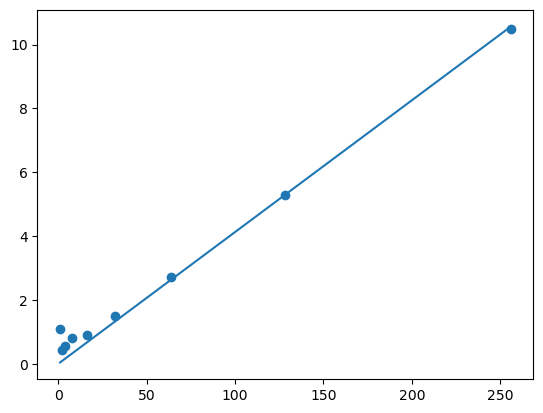

In [92]:
m, b = np.polyfit(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times'], 1)
slope = np.dot(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times']) / np.dot(pipeline_test['sizes'], pipeline_test['sizes'])

plt.scatter(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times'])
plt.plot(pipeline_test['sizes'][:len(pipeline_test['times'])], np.array(pipeline_test['sizes'][:len(pipeline_test['times'])]) * slope)


seems like batch size does not really matter for generation speed- seconds/sample stays the same. 

(array([1232349.,  745020., 1084634., 1470926., 1759822., 1759558.,
        1474366., 1084381.,  743111., 1228745.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

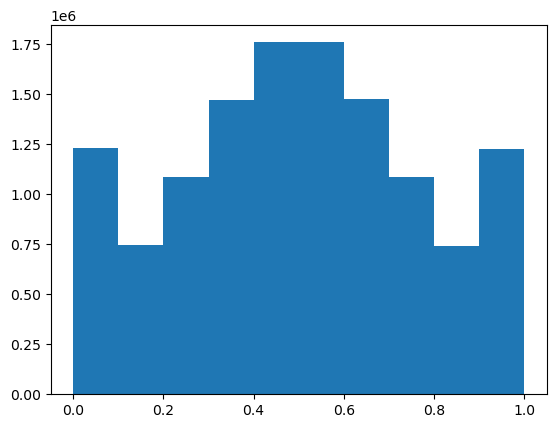

In [93]:
plt.hist(np.array(pipeline_test['batches'][-1]).flatten())

In [94]:
images = np.transpose(images, (0, 3, 1, 2))
images.shape

(256, 128, 16, 24)

In [ ]:
plt.imshow(images[0, 59])

### Comparing empirical dataset norms to saved

In [ ]:
from climsim_data_utils import data_utils, load_vars

In [ ]:
mapper = fs.get_mapper("gs://leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.grid-info.zarr")
grid_info = xr.open_dataset(mapper, engine='zarr')

dutils = data_utils(grid_info=grid_info)

In [ ]:
def reconstruct_np(X_norm, Y_norm, data_vars='v1'):
    inputs, outputs = load_vars(data_vars)
    input_mean = xr.open_dataset('Climsim_info/input_mean.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    input_max = xr.open_dataset('Climsim_info/input_max.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    input_min = xr.open_dataset('Climsim_info/input_min.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    output_scale = xr.open_dataset('Climsim_info/output_scale.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values

    X = X_norm*(input_max - input_min) + input_mean
    Y = Y_norm / output_scale
    return(X,Y)

In [ ]:
x_avg = x_npy.mean(axis=0)
x_avg.shape

In [ ]:
x_norm = xr.open_dataset("Climsim_info/input_mean.nc")

In [64]:
x_norm_v1 = x_norm[dutils.v1_inputs].to_stacked_array('mlvar', sample_dims='').values

In [75]:
(x_avg -x_norm_v1)

array([-2.56817731e-02,  4.18193672e-02,  9.98839433e-03,  6.54797630e-05,
        2.16402490e-03, -2.84236218e-03, -7.80040626e-03, -7.79458220e-04,
        6.23871345e-03,  5.40563035e-03,  2.17198329e-03,  3.37880128e-04,
       -5.97191006e-04, -9.69804839e-04,  5.85265309e-04,  1.21450536e-03,
       -3.11999986e-03, -3.44376894e-03,  5.46327227e-03,  7.97039341e-03,
        6.71671362e-03,  5.06742930e-03,  2.17408058e-03, -1.35648329e-03,
       -4.15770949e-03, -6.98711656e-03, -9.16070289e-03, -1.06326176e-02,
       -1.12655234e-02, -1.12312231e-02, -1.09699861e-02, -1.07240824e-02,
       -1.05749213e-02, -1.01690826e-02, -9.24284257e-03, -7.57338261e-03,
       -5.09230842e-03, -2.87782532e-03, -1.14609395e-03,  4.11092162e-04,
        1.60435950e-03,  2.65040335e-03,  3.15641661e-03,  3.28444663e-03,
        3.01585356e-03,  2.99826758e-03,  4.39359316e-03,  7.46977212e-03,
        1.22814718e-02,  1.88928090e-02,  2.60559371e-02,  3.35944514e-02,
        4.12411248e-02,  

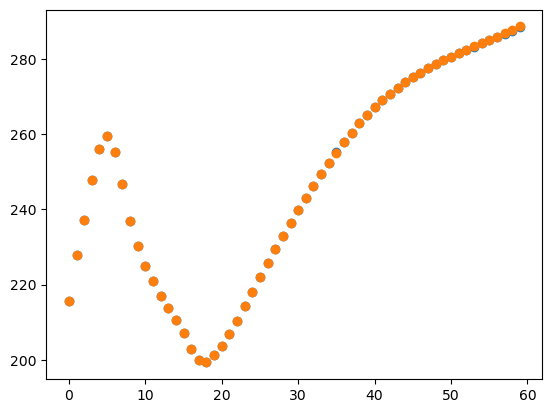

In [69]:
plt.scatter(np.arange(60), x_norm_v1[:60])
plt.scatter(np.arange(60), x_avg[:60])

In [45]:
output_scaling = xr.open_dataset("Climsim_info/output_scale.nc")

oscaling  = output_scaling[dutils.v1_outputs].to_stacked_array('mlvar', sample_dims='').values

In [52]:
y_avg = y_npy.mean(axis=0)
y_scale_test = 1./ y_avg

/tmp/ipykernel_626/3185387537.py:2: RuntimeWarning: divide by zero encountered in divide
  y_scale_test = 1./ y_avg


In [54]:
y_avg

array([ 1.19014050e-05, -1.13608688e-05, -5.22001272e-06, -1.83795208e-06,
       -1.83506310e-06,  7.04202705e-07,  1.36045056e-06,  8.66873477e-07,
        1.65614915e-08, -9.96006355e-08,  3.42032446e-07,  5.19593379e-07,
        6.27532105e-07,  6.53872793e-07,  7.57789509e-07,  1.05315910e-06,
        1.64673863e-06,  1.35920795e-06,  6.38992441e-07, -5.41416933e-07,
       -6.43335666e-09, -2.26299367e-06, -3.69347862e-06, -5.13319715e-06,
       -6.32380659e-06, -6.27994870e-06, -5.32568580e-06, -4.25518677e-06,
       -3.33941632e-06, -2.52159343e-06, -1.73624515e-06, -1.34164169e-06,
       -6.12715034e-07,  1.00480138e-07,  6.40130091e-07,  8.57316853e-07,
        1.44235977e-06,  1.70224506e-06,  1.48805081e-06,  1.39098697e-06,
        1.65367745e-06,  2.02146425e-06,  1.71443179e-06,  1.11403501e-06,
        1.36902466e-06,  1.54391288e-06,  2.10816170e-06,  3.53536307e-06,
        4.23332185e-06,  5.19102267e-06,  4.95795627e-06,  6.65066905e-06,
        7.07406187e-06,  

In [53]:
y_scale_test

array([ 8.40236928e+04, -8.80214374e+04, -1.91570414e+05, -5.44083826e+05,
       -5.44940390e+05,  1.42004567e+06,  7.35050598e+05,  1.15357088e+06,
        6.03810352e+07, -1.00400966e+07,  2.92369923e+06,  1.92458187e+06,
        1.59354397e+06,  1.52934945e+06,  1.31962767e+06,  9.49524147e+05,
        6.07260911e+05,  7.35722592e+05,  1.56496374e+06, -1.84700540e+06,
       -1.55439851e+08, -4.41892530e+05, -2.70747472e+05, -1.94810363e+05,
       -1.58132604e+05, -1.59236969e+05, -1.87769245e+05, -2.35007311e+05,
       -2.99453528e+05, -3.96574637e+05, -5.75955532e+05, -7.45355490e+05,
       -1.63208008e+06,  9.95221566e+06,  1.56218246e+06,  1.16642989e+06,
        6.93308299e+05,  5.87459482e+05,  6.72020063e+05,  7.18913996e+05,
        6.04712847e+05,  4.94690916e+05,  5.83283632e+05,  8.97637854e+05,
        7.30447030e+05,  6.47704940e+05,  4.74346915e+05,  2.82856380e+05,
        2.36221113e+05,  1.92640268e+05,  2.01696010e+05,  1.50360812e+05,
        1.41361500e+05,  

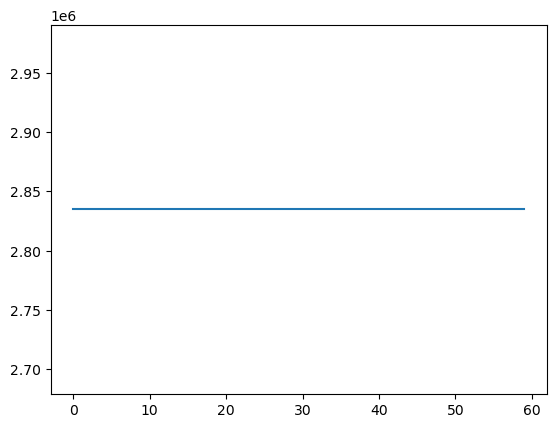

In [56]:
plt.plot(np.arange(60), oscaling[60:120])
#plt.plot(np.arange(60), y_scale_test[60:120])

In [33]:
oscaling.values()

ValuesView(<xarray.Dataset> Size: 1kB
Dimensions:         (lev: 60)
Dimensions without coordinates: lev
Data variables:
    ptend_t         (lev) float64 480B ...
    ptend_q0001     (lev) float64 480B ...
    cam_out_NETSW   float64 8B ...
    cam_out_FLWDS   float64 8B ...
    cam_out_PRECSC  float64 8B ...
    cam_out_PRECC   float64 8B ...
    cam_out_SOLS    float64 8B ...
    cam_out_SOLL    float64 8B ...
    cam_out_SOLSD   float64 8B ...
    cam_out_SOLLD   float64 8B ...)

# Image Metrics

In [19]:
pipeline_generator.set_num_images(32)
dimages = next(iter(pipeline_generator))

  0%|          | 0/100 [00:00<?, ?it/s]

In [20]:
images = train_ds[0]

In [21]:
images.shape

torch.Size([32, 128, 16, 24])

### SSIM

In [22]:
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM

In [90]:
ssim = SSIM(data_range=1.0).to(device)

In [92]:
sssim = SSIM(data_range=1.0)

In [94]:
%%time
sssim(images, dimages.detach().cpu())

CPU times: user 1.24 s, sys: 188 ms, total: 1.43 s
Wall time: 228 ms


tensor(0.0051)

In [87]:
dimages.device

device(type='cuda', index=0)

In [88]:
device

'cuda'

In [95]:
%%time
ssim(images.to(device), dimages)

CPU times: user 3.33 ms, sys: 143 µs, total: 3.48 ms
Wall time: 3.18 ms


tensor(0.0051, device='cuda:0')

## Spectral

In [24]:
dim_ftt = torch.fft.fft(dimages)

In [33]:
dim_ftt.shape, dimages.shape

mag, phase = torch.abs(dim_ftt), torch.angle(dim_ftt) 

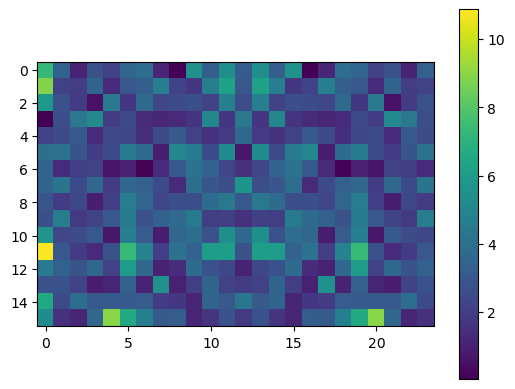

In [40]:
plt.imshow(mag[0][59].detach().cpu().numpy())
plt.colorbar()
plt.show()

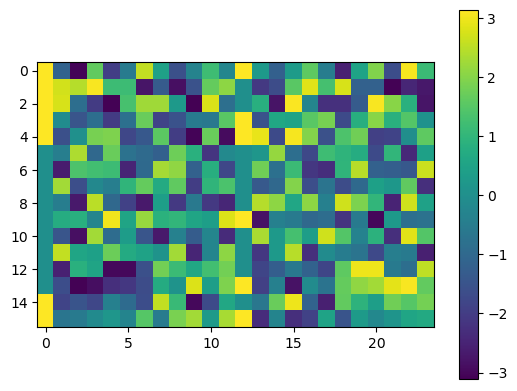

In [39]:
plt.imshow(phase[0][59].detach().cpu().numpy())
plt.colorbar()
plt.show()

# Evaluating

Ok so we have a diffusion model... is it any good?

In [104]:
model_to_test = 'a'

ddpm = diff_models[model_to_test]
ddpm.device

device(type='cuda', index=0)

In [94]:
from ipywidgets import interact, widgets

In [ ]:
num_images = 100

In [102]:
indices = np.random.randint(0, ds.data.time.size, size=num_images)
items = ds.data.isel(time=indices).load()

In [105]:
real_images = create_sample(items, ds)

In [106]:
pipeline = diffusers.DDIMPipeline(ddpm, scheduler)

[Check Pipeline Source Code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/ddim/pipeline_ddim.py)

### Test 0: Inspecting Generated Images

In [20]:
dsi, dso = diff.climsim_utils.load_raw_dataset(dconfig)

In [21]:
dso.sizes

Frozen({'time': 10952, 'lev': 60, 'ncol': 384})

(array([1.555500e+04, 3.600684e+06, 1.298322e+06, 5.780000e+02,
        5.200000e+01, 6.000000e+00, 1.000000e+00, 0.000000e+00,
        1.000000e+00, 1.000000e+00]),
 array([-17.2358284 ,  -8.02222061,   1.19138718,  10.40499496,
         19.61860275,  28.83221054,  38.04581833,  47.25942612,
         56.47303391,  65.68664551,  74.90024567]),
 <BarContainer object of 10 artists>)

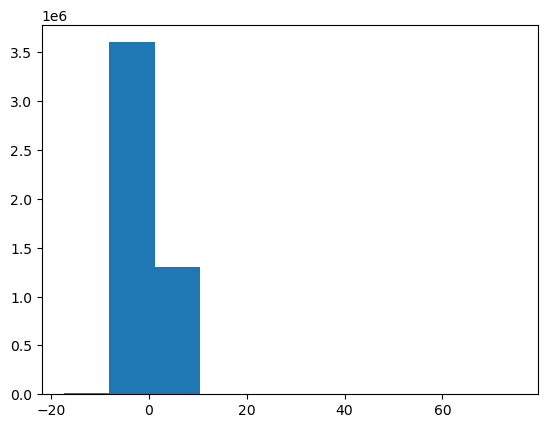

In [24]:
plt.hist(real_images.flatten())

In [25]:
pipeline_generator.set_num_images(10)
gen = iter(pipeline_generator)

In [26]:
fake_images = next(gen)

  0%|          | 0/100 [00:00<?, ?it/s]

In [27]:
fake_images.shape

torch.Size([10, 128, 16, 24])

In [28]:
faked_images = recreate_sample(fake_images)

In [29]:
faked_images.sizes

Frozen({'time': 10, 'ncol': 384, 'mlo': 128})

In [58]:


def interactive_image_viewer(images, cmap='viridis', dataset=train_ds):
    """
    Interactive viewer to display a 2D slice from a 4D array of images.
    
    Parameters:
    images (np.ndarray): A numpy array of shape (100, 128, 16, 24), representing 100 sets of maps,
                         each containing 128 variables, each of size 16x24.
    """
    # Define interactive plot function
    def plot_image(index, variable):
        vmap = images.isel(time=index, mlo=variable, ncol=dataset.permute_indices).data
        plt.imshow(vmap.reshape(16,24), cmap=cmap)
        plt.colorbar()
        plt.title(f"Image {index + 1} - Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = images.time.size, images.mlo.size
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
interactive_image_viewer(faked_images)

interactive(children=(IntSlider(value=0, description='Index:', max=9), IntSlider(value=0, description='Variabl…

### Test One: Using DDPM as Encoder-Decoder
Let's imagine $x_{in} \in \mathbb{R}^{C \times H \times W}$ is the output of your ML emulator. I want to perturb $x$ to a noisy sample $z_t$; the larger the t, the further away I am taking from the image manifold before denoising back. 



Encoding: Noising a sample $$x_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon$$

Decoding: De-Noising it and bring it closer to distribution
$$\epsilon_{\theta} = DDPM(z_t, t)$$
$$x_{t-1} \sim p_{\theta}(x_{t-1}|x_t) = \dfrac{1}{\sqrt{\alpha_t}}\left( x_t - \dfrac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_{\theta}\right) + \sigma_t z, z\sim \mathcal{N}(0, 1)$$


In [107]:
scheduler.set_timesteps(100)

In [108]:
real_images.shape

torch.Size([100, 128, 16, 24])

In [112]:
pipeline_generator = SampleImages(ddpm, scheduler)

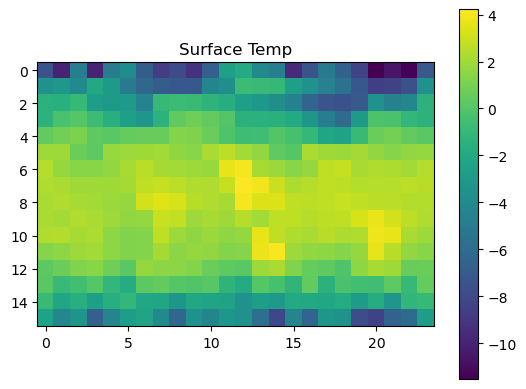

In [110]:
plt.imshow(real_images[0, 59])
plt.title("Surface Temp")
plt.colorbar()
plt.show()

In [125]:
x_noisy, eps = pipeline_generator.encode(real_images.to(device), 99)

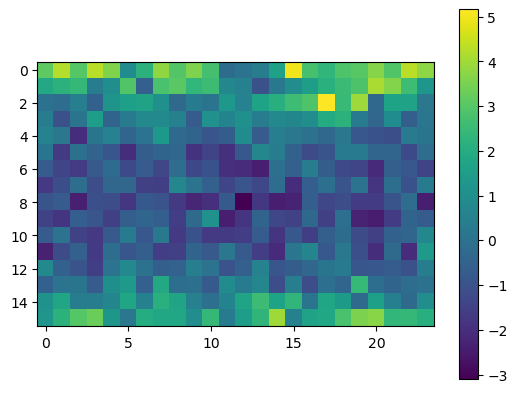

In [126]:
plt.imshow((x_noisy.detach().cpu() - real_images)[0, 59])
plt.colorbar()

Text(0.5, 1.0, 'Surface Temp, noisy')

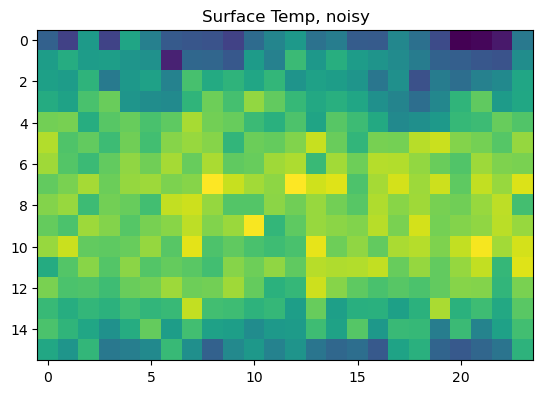

In [127]:
plt.imshow(x_noisy.detach().cpu()[0, 59])
plt.title("Surface Temp, noisy")

In [128]:
history = pipeline_generator.decode(x_noisy, 10)

  0%|          | 0/11 [00:00<?, ?it/s]

In [129]:
history.keys()

dict_keys([11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

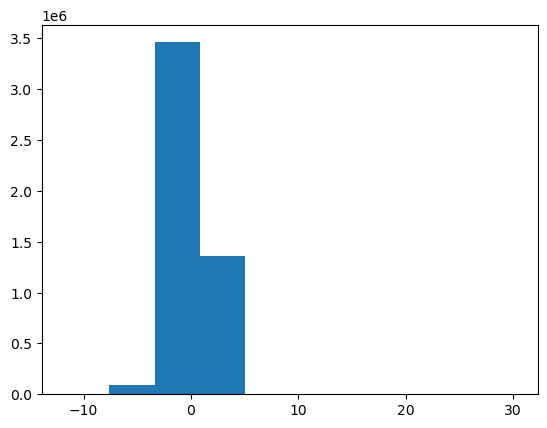

In [136]:
def hist(images, **kwargs):
    if(isinstance(images, torch.Tensor)):
        images = images.detach().cpu().numpy()
    plt.hist(images.flatten(), **kwargs)
t = 4
hist(history[t])

In [134]:
history[11].device

device(type='cuda', index=0)

In [140]:
def plot_histogram_evolution(history):
    def plot_timestep(t):
        plt.figure(figsize=(10, 6))
        hist(history[t], bins=50, density=True)
        plt.title(f'Distribution at Denoising Step {t}')
        plt.xlabel('Values')
        plt.ylabel('Density')
        plt.grid(True)
        plt.show()
    
    # Create slider for time steps
    t_slider = widgets.IntSlider(
        value=max(history.keys()),
        min=0,
        max=max(history.keys()),
        step=1,
        description='Time Step:',
        continuous_update=False
    )
    
    # Display interactive plot
    interact(plot_timestep, t=t_slider)

plot_histogram_evolution(history)

interactive(children=(IntSlider(value=11, continuous_update=False, description='Time Step:', max=11), Output()…

(array([2.275000e+03, 2.197730e+05, 4.459015e+06, 2.333450e+05,
        6.860000e+02, 7.800000e+01, 2.100000e+01, 5.000000e+00,
        1.000000e+00, 1.000000e+00]),
 array([-17.08908272, -10.36155987,  -3.63403702,   3.09348488,
          9.82100868,  16.54853249,  23.27605247,  30.00357628,
         36.73110199,  43.45862579,  50.18614578]),
 <BarContainer object of 10 artists>)

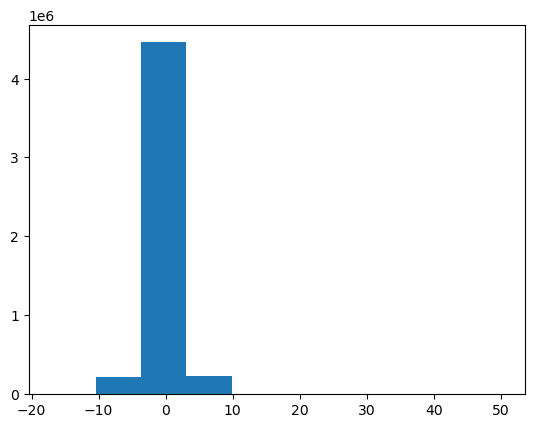

In [139]:
plt.hist(real_images.flatten())

In [121]:
fake_images = next(iter(pipeline_generator))

  0%|          | 0/100 [00:00<?, ?it/s]

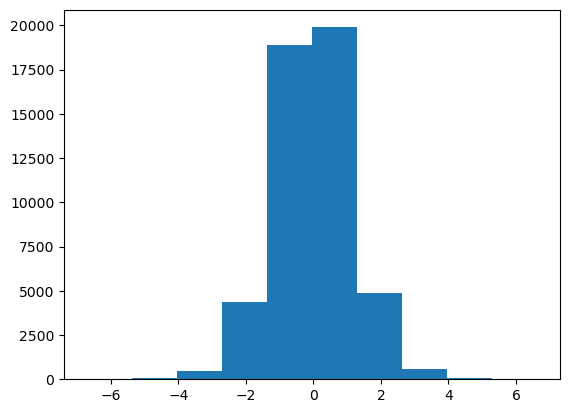

In [142]:
hist(fake_images.flatten())

In [143]:
history[5].device, history[5].shape

(device(type='cpu'), torch.Size([100, 128, 16, 24]))

In [144]:
rec_images = recreate_sample(history[5])

In [145]:
rec_images

<xarray.DataArray (time: 100, ncol: 384, mlo: 128)> Size: 39MB
array([[[ 2.14232480e+02,  2.18942508e+02,  2.35673379e+02, ...,
          1.18377451e+02,  1.66332342e+02,  8.41206834e+01],
        [ 2.13744013e+02,  2.21163137e+02,  2.30718838e+02, ...,
         -1.87286818e+01,  1.47169316e+02,  1.07874069e+02],
        [ 2.08666279e+02,  2.30361540e+02,  2.29404037e+02, ...,
          6.82864153e+01,  7.50906185e+01,  8.59183353e+00],
        ...,
        [ 2.24519541e+02,  2.25416249e+02,  2.47359002e+02, ...,
          5.69536170e+01, -3.86359338e+01,  4.85816085e+00],
        [ 2.10682767e+02,  2.29778470e+02,  2.32988194e+02, ...,
         -1.59208823e+00,  6.04601089e+01,  1.93712784e+01],
        [ 2.14213985e+02,  2.46366418e+02,  2.43542868e+02, ...,
          3.22050847e+01, -2.28249005e+01, -4.24494747e+00]],

       [[ 2.17668126e+02,  2.24283177e+02,  2.22847988e+02, ...,
          2.27590974e+01, -7.02963520e+00,  1.33947951e+01],
        [ 2.09293013e+02,  2.24233577e+02,  2.20743847e+02, ...,
          3.77734902e+01,  2.78761166e+01,  1.03140154e+00],
        [ 2.15671703e+02,  2.38860201e+02,  2.32455898e+02, ...,
         -6.80909399e+01, -9.24296968e+01,  2.32879222e+00],
...
        [ 2.11496439e+02,  2.40175102e+02,  2.48454427e+02, ...,
          2.97197374e+00,  7.46002996e+00,  2.29282542e+00],
        [ 2.19294167e+02,  2.29240067e+02,  2.40204597e+02, ...,
          9.21211970e+01, -7.98499343e+00, -3.25708507e+00],
        [ 2.09457265e+02,  2.19400061e+02,  2.29180626e+02, ...,
         -6.54631263e+00,  4.39282153e+01, -8.36107399e+00]],

       [[ 2.15000739e+02,  2.24031973e+02,  2.32106979e+02, ...,
          8.29491166e+01,  3.56038466e+01, -1.43484981e+01],
        [ 2.19889888e+02,  2.33361427e+02,  2.50077309e+02, ...,
          1.73599607e+02,  4.09219422e+01,  1.67869135e+01],
        [ 2.19900454e+02,  2.25999060e+02,  2.38777806e+02, ...,
         -8.99561425e+01,  7.79025082e+00,  2.34202567e+01],
        ...,
        [ 2.07700781e+02,  2.36788561e+02,  2.52054002e+02, ...,
          1.95960766e+02,  2.38085278e+01,  3.08336423e+01],
        [ 2.15825447e+02,  2.37474883e+02,  2.38029822e+02, ...,
          6.11871308e+01, -3.35222890e+01,  4.73340287e+01],
        [ 2.24057126e+02,  2.22342115e+02,  2.45101401e+02, ...,
          1.05993817e+02, -4.54967231e+01,  2.07318192e+01]]])
Coordinates:
  * time      (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
  * mlo       (mlo) object 1kB MultiIndex
  * variable  (mlo) object 1kB 'state_t' 'state_t' ... 'cam_out_SOLLD'
  * lev       (mlo) object 1kB 0 1 2 3 4 5 6 7 ... nan nan nan nan nan nan nan
  * ncol      (ncol) int64 3kB 0 1 2 3 4 5 6 7 ... 377 378 379 380 381 382 383

In [146]:
real_images.shape

torch.Size([100, 128, 16, 24])

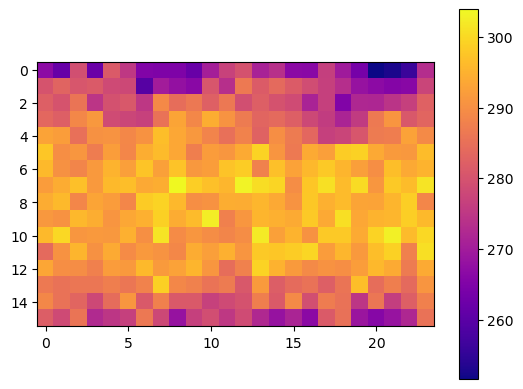

In [147]:
recreate_sample(history[5])
data = rec_images.isel(time=0, mlo=[59, 28], ncol=dataset.permute_indices).data
temp_map = data[:, 0] # mlvar 59 is temperature
humidity_map = data[:, 1] # mlvar 28 is temperature
plt.imshow(temp_map.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [71]:
max(history.keys())

26

In [149]:
def plot_denoising_history_old(history):
    images_to_show = []
    for t in range(T, 0, stride):
        images_to_show.append((t, recreate_sample(history[t].detach().cpu())))
    images_to_show.append((t, recreate_sample(history[0].detach().cpu())))
    # Set up the figure for displaying images
    fig, axes = plt.subplots(len(mlvars), len(images_to_show), figsize=(len(images_to_show) * 5, 5))
    plt.subplots_adjust(wspace=0, hspace=0)
    # Plot each image in the carousel
    for var_idx, mlvar in enumerate(mlvars):
        for img_idx, (t, img) in enumerate(images_to_show):
            variable_map = img.isel(time=idx, mlo=mlvar, ncol=dataset.permute_indices).data.reshape(16, 24)
            axes[var_idx, img_idx].imshow(variable_map, cmap='plasma')
            axes[var_idx, img_idx].axis('off')
            axes[var_idx, img_idx].set_title(f'{dataset.mlo[mlvar].item()}, t={t}')
    plt.tight_layout()
    plt.show()
    #return(images_to_show)

def denoising_history(history, cmap='plasma', dataset=ds):
    # Define interactive plot function
    def plot_image(index, variable, denoise_step):
        vmap = recreate_sample(history[denoise_step]).isel(time=index, mlo=variable, ncol=dataset.permute_indices).data
        plt.imshow(vmap.reshape(16,24), cmap=cmap)
        plt.colorbar()
        plt.title(f"Image {index + 1} - Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = history[0].shape[:2]
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    noise_slider = widgets.IntSlider(value=0, min=0, max=max(history.keys()), step=1, description='Denoising step:')
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider, denoise_step=noise_slider)


In [150]:
denoising_history(history)

interactive(children=(IntSlider(value=0, description='Index:', max=99), IntSlider(value=0, description='Variab…

In [151]:
history.keys()

dict_keys([11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [153]:
#plot_denoising_carousel(history, 25, stride=-5, idx=0, mlvars=[59, 110])



In [154]:
mlvars, idx = [59, 110], 0

In [155]:
list(enumerate(mlvars))

[(0, 59), (1, 110)]

In [122]:
#data = images_to_show[0].isel(time=0, mlo=59, ncol=train_ds.permute_indices).data

In [124]:
#fig, axes = plt.subplots(1, 5, figsize=(5 * 5, 5))
#axes[0, 0].plot([1, 2, 3], [1, 2, 4])
#axes

In [125]:
#imgs = plot_denoising_carousel(history, 25, stride=-5, idx=0, mlvars=[59, 110])

In [156]:
def encode(sample, t):
    eps = torch.randn(sample.shape, device=device) # BS x C x H x W
    xt = scheduler.add_noise(sample, eps, torch.LongTensor([t])) # noisy image
    return(xt, eps)

In [157]:
def decode(xt, T, unet=ddpm, scheduler=scheduler, track_history=True):
    if track_history:
        history = {T : xt}
    for t in range(T, 0, -1): # pipe.scheduler.timesteps[-T//stride-1:]
        with torch.no_grad():
            eps_theta = unet(xt, t).sample
        x_prev = scheduler.step(eps_theta, t, xt)
        xt = x_prev.prev_sample
        if track_history:
            history[t-1] = xt
    return(xt, history)

In [33]:
print(real_images.shape)
dataset[5].shape


torch.Size([100, 128, 16, 24])


torch.Size([32, 128, 16, 24])

In [158]:
def encode_decode_dists(dataset, index, T, unet=ddpm, scheduler=scheduler, pure_noise=False, verbose=False):
    start = time.time()
    if pure_noise:
        x0 = torch.randn(dataset[index].shape, device=device)
    else:
        x0 = dataset[index].to(device)
    
    if(verbose):
        print(f"Loaded item after {time.time() - start} seconds; denoising to step {T}")
    distances = []
    dist = torch.nn.MSELoss()
    for t in range(T):
        xt, eps = encode(x0, t)
        distances.append(dist(x0, xt).item())

    for t in range(T, 0, -1): # pipe.scheduler.timesteps[-T//stride-1:]
        with torch.no_grad():
            eps_theta = unet(xt, t).sample
        x_prev = scheduler.step(eps_theta, t, xt)
        xt = x_prev.prev_sample
        distances.append(dist(x0, xt).item())
    return(np.array(distances))

In [161]:
print(len(ds))
num_batches = 5
indices = torch.randint(0, len(ds), (num_batches,))
indices

1642


tensor([ 374,  545, 1014,  129, 1518])

In [164]:
Ts = [10, 25, 40]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(ds, int(indices[0]), T, pure_noise=False, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(ds, int(index), T, pure_noise=False, verbose=True)

Loaded item after 3.162961959838867 seconds; denoising to step 10
Loaded item after 2.6597723960876465 seconds; denoising to step 10
Loaded item after 1.5729613304138184 seconds; denoising to step 10
Loaded item after 3.1810519695281982 seconds; denoising to step 10
Loaded item after 2.630091905593872 seconds; denoising to step 10
Loaded item after 3.154933452606201 seconds; denoising to step 25
Loaded item after 2.561497688293457 seconds; denoising to step 25
Loaded item after 1.6509654521942139 seconds; denoising to step 25
Loaded item after 3.0155231952667236 seconds; denoising to step 25
Loaded item after 1.9074945449829102 seconds; denoising to step 25
Loaded item after 2.96115779876709 seconds; denoising to step 40
Loaded item after 2.927957773208618 seconds; denoising to step 40
Loaded item after 2.0010581016540527 seconds; denoising to step 40
Loaded item after 3.341028928756714 seconds; denoising to step 40
Loaded item after 1.6242749691009521 seconds; denoising to step 40


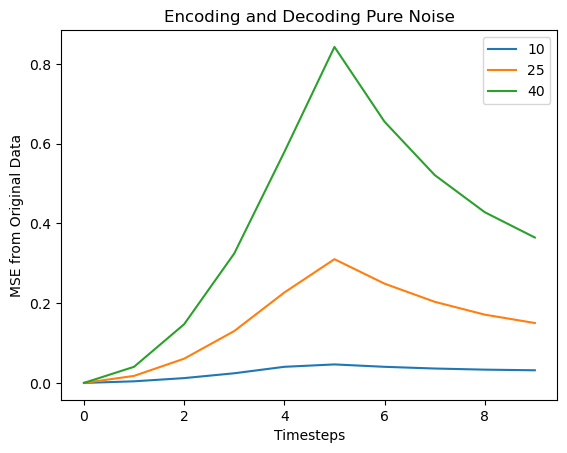

In [167]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[40][::8], label=40)
plt.legend()
plt.title(f"Encoding and Decoding Pure Noise")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

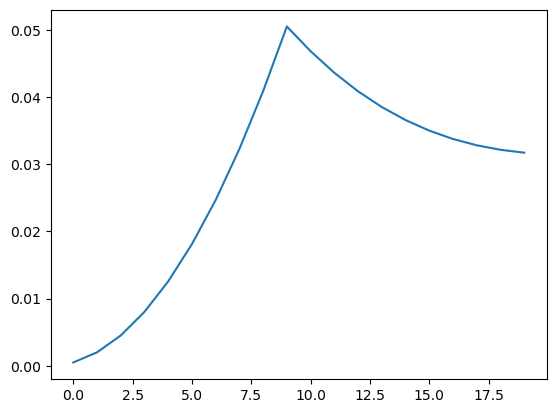

In [168]:
plt.plot(data[10], label=10)

In [162]:
Ts = [10, 25, 50]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(ds, int(indices[0]), T, pure_noise=True, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(ds, int(index), T, pure_noise=True, verbose=True)

Loaded item after 4.396990060806274 seconds; denoising to step 10
Loaded item after 3.642996072769165 seconds; denoising to step 10
Loaded item after 1.7694494724273682 seconds; denoising to step 10
Loaded item after 3.897876024246216 seconds; denoising to step 10
Loaded item after 1.7067029476165771 seconds; denoising to step 10
Loaded item after 3.133835792541504 seconds; denoising to step 25
Loaded item after 2.673884868621826 seconds; denoising to step 25
Loaded item after 1.831925868988037 seconds; denoising to step 25
Loaded item after 3.1042847633361816 seconds; denoising to step 25
Loaded item after 1.7621901035308838 seconds; denoising to step 25
Loaded item after 3.0666892528533936 seconds; denoising to step 50
Loaded item after 2.859802722930908 seconds; denoising to step 50
Loaded item after 1.6939847469329834 seconds; denoising to step 50
Loaded item after 2.9515795707702637 seconds; denoising to step 50
Loaded item after 1.8375880718231201 seconds; denoising to step 50


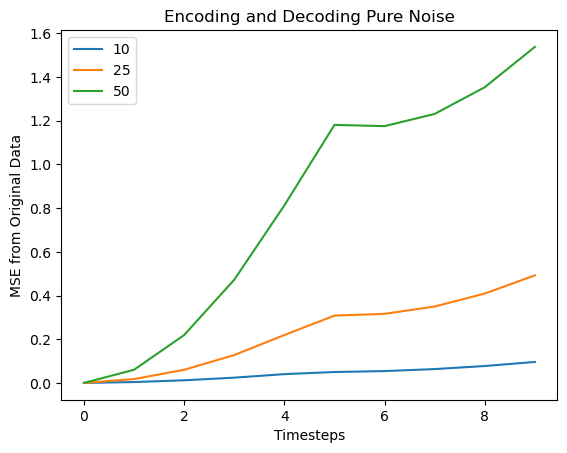

In [163]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[50][::10], label=50)
plt.legend()
plt.title(f"Encoding and Decoding Pure Noise")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

In [156]:
Ts = [10, 25, 50]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(train_ds, int(indices[0]), T, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(train_ds, int(index), T, verbose=True)

Loaded item after 0.621530294418335 seconds; denoising to step 10
Loaded item after 1.1254692077636719 seconds; denoising to step 10
Loaded item after 1.1418592929840088 seconds; denoising to step 10
Loaded item after 1.1139025688171387 seconds; denoising to step 10
Loaded item after 1.14725923538208 seconds; denoising to step 10
Loaded item after 0.5982179641723633 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5726149082183838 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5611705780029297 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5395488739013672 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.559136152267456 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5664746761322021 seconds; denoising to step 50
Decoded to step  50
Decoded to step  25
Loaded item after 0.777012825012207 seconds; denoising to step 50
Decoded to step  50
Decoded to step  25
Loaded item after 0.5

In [159]:
for key, value in data.items():
    data[key] = value / len(indices)

In [161]:
data[10]

array([0.00010001, 0.00040108, 0.00090285, 0.00160852, 0.00251562,
       0.00362387, 0.00493786, 0.00645424, 0.00817317, 0.01011272,
       0.00975462, 0.00944947, 0.00919356, 0.00898288, 0.00881219,
       0.00867608, 0.0085698 , 0.00848928, 0.00843116, 0.00839389])

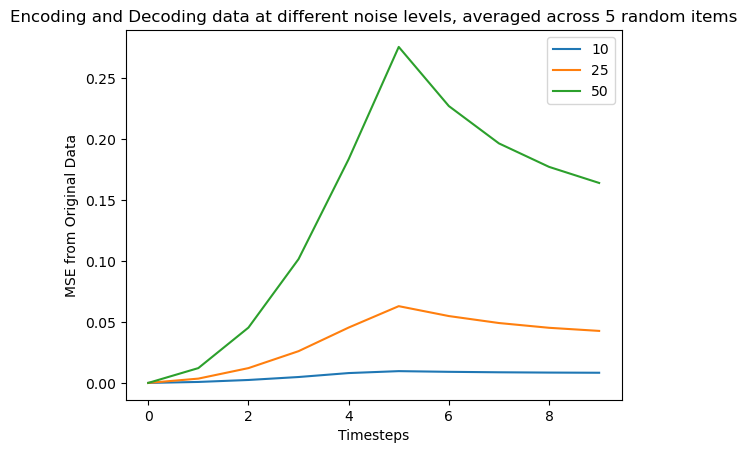

In [163]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[50][::10], label=50)
plt.legend()
plt.title(f"Encoding and Decoding data at different noise levels, averaged across {len(indices)} random items")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

In [120]:
for key, value in data.items():
    data[key] = list(value)

In [121]:
with open("images/ED_difftest.json", 'w') as file:
    json.dump(data, file)

In [112]:
data[25]

array([0.00010004, 0.00040101, 0.00090381, 0.00160752, 0.0025139 ,
       0.00362368, 0.00493781, 0.00646016, 0.00817705, 0.01011331,
       0.00920108, 0.00841366, 0.00774693, 0.00719623, 0.00675461,
       0.00641415, 0.00616434, 0.00599223, 0.00588539, 0.00582726])

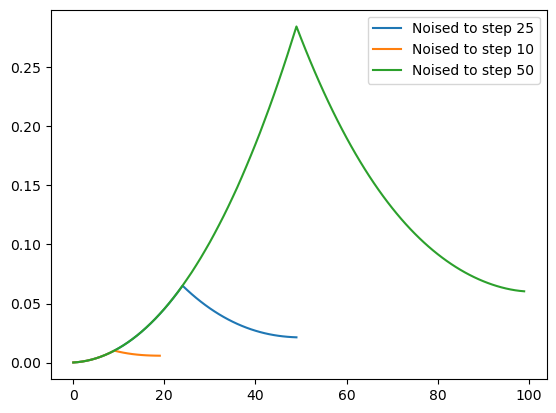

In [106]:
for t in data.keys():
    plt.plot(data[t], label=f'Noised to step {t}')

plt.legend()
plt.show()

In [104]:
encode_decode_dists(train_ds, 64, 99, verbose=True)

KeyboardInterrupt: 

In [102]:
for t in [99]:
    print("At time ", t)
    distances = 0
    for index in torch.randint(0, len(train_ds), (num_batches,)).numpy():
        print(index, end=" ")
        distances = distances + encode_decode_dists(train_ds, int(index), t)

    data[t] = distances / num_batches



At time  99
62 

KeyboardInterrupt: 

In [75]:
ds = encode_decode_dists(train_ds, 83, 25)

Loaded item after 13.758191585540771 seconds


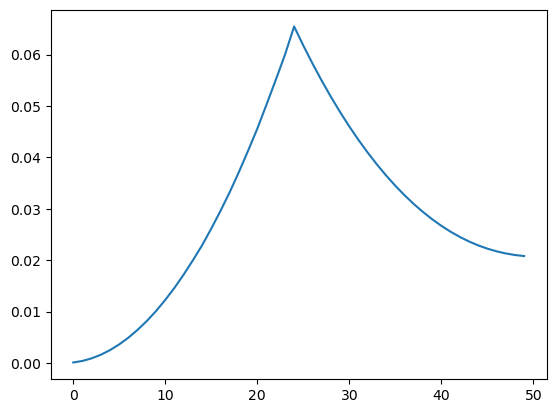

In [65]:
plt.plot(ds)

In [59]:
%%time
item = train_ds[26]

CPU times: user 10.4 s, sys: 7.34 s, total: 17.7 s
Wall time: 14.1 s


In [26]:
item.shape

torch.Size([32, 128, 16, 24])

In [27]:
x25, eps = encode(item.to(device), 25)

In [28]:
x0_hat, history25 = decode(x25, 25)

In [44]:
dist = torch.nn.MSELoss()
history25['diffs'] = []
for t in list(history25.keys()):
    if isinstance(t, int):
        history25['diffs'].append(dist(item.to(device), history25[t]).item())

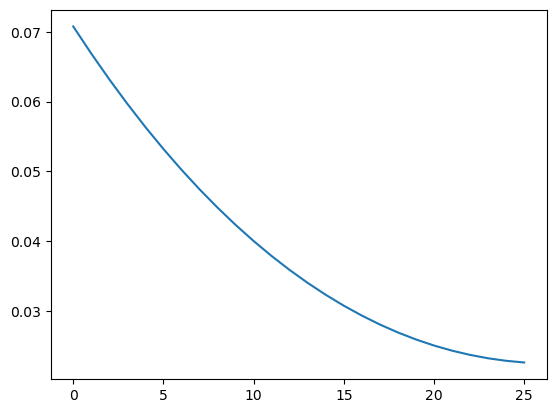

In [48]:
#plt.plot(history['diffs'])
plt.plot(history25['diffs'])

#### How it works

In [40]:
t = 25

In [41]:
zt, eps = encode(item, 25)

In [52]:
zt.shape

torch.Size([128, 128, 16, 24])

In [48]:
at = scheduler.alphas_cumprod[t]
zt_manual = torch.sqrt(at) * item + torch.sqrt(1-at)*eps

(zt_manual == zt).all().item()

True

In [55]:
with torch.no_grad():
    eps_theta = ddpm(zt.to(device), torch.tensor([25], device=device))

In [97]:
x24 = ddim_scheduler.step(eps_theta.sample, 25, zt.to(device)).prev_sample

In [98]:
x24.shape

torch.Size([128, 128, 16, 24])

In [86]:
a24 = ddim_scheduler.alphas_cumprod[24]
a25 = ddim_scheduler.alphas_cumprod[25]

DDIM Sampling:
$$x_{t-1} = \sqrt{\alpha_{t-1}}\left( \dfrac{x_t - \sqrt{1-\alpha_t} \epsilon_\theta}{\sqrt{\alpha_t}}\right) + \sqrt{1-\alpha_{t-1}} \cdot \epsilon_\theta$$

If taking larger strides, can replace $\alpha_{t-1}$ with $\alpha_{t-n}$

In [92]:
x24_manual = (zt.to(device) - torch.sqrt(1 - a25) * eps_theta.sample) / torch.sqrt(a25)
x24_manual = torch.sqrt(a24) * x24_manual + torch.sqrt(1 - a24) * eps_theta.sample

In [100]:
(x24 == x24_manual).all().item()

True

In [ ]:
scheduler.set_timesteps(50)
print(scheduler.timesteps) # x_t-1 becomes x80 | x90
print(scheduler.config.num_train_timesteps, scheduler.num_inference_steps)
scheduler.set_timesteps(100)

In [ ]:
T, stride = 20, 2
scheduler.set_timesteps(scheduler.config.num_train_timesteps // stride)
scheduler.timesteps[-T//stride-1:]

(array([ 9904.,  3771.,  3695.,  3560.,  3080.,  2686.,  2812.,  2961.,
         3787., 12896.]),
 array([-1.        , -0.80000001, -0.60000002, -0.40000001, -0.2       ,
         0.        ,  0.2       ,  0.40000001,  0.60000002,  0.80000001,
         1.        ]),
 <BarContainer object of 10 artists>)

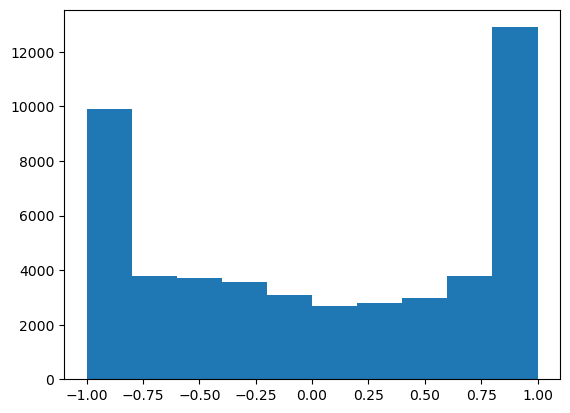

In [176]:
plt.hist(denoised_image.flatten()) # x0_reconstructed

(array([2.9500e+02, 3.8060e+03, 1.7294e+04, 2.0226e+04, 6.8030e+03,
        6.2800e+02, 8.1000e+01, 1.4000e+01, 3.0000e+00, 2.0000e+00]),
 array([-3.71876931, -2.53953576, -1.36030233, -0.18106887,  0.99816459,
         2.1773982 ,  3.35663152,  4.53586483,  5.71509838,  6.89433193,
         8.07356548]),
 <BarContainer object of 10 artists>)

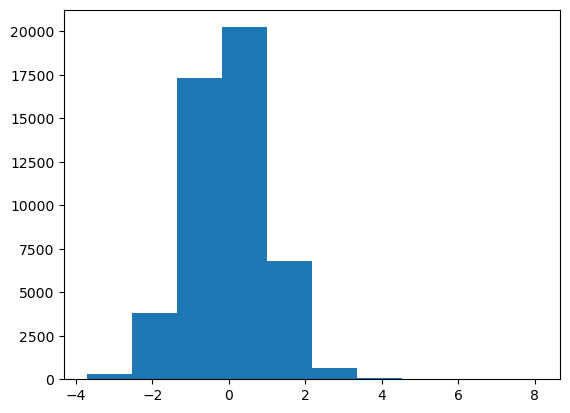

In [154]:
plt.hist(train_ds[0].flatten())

## Distribution Metrics

Series of evaluation metrics between two datasets $\mathcal S_r$ (training corpus) and $\mathcal S_f$ (generated images) respectively. Idea is to use N samples from each learned distribution and rate model on some kind of distribution distance metric. 

In [ ]:
vae_exp_id = "VAE_August05_08:23"
vae_log_pth = "trial_log.json"
with open(os.path.join("experiments", vae_exp_id, vae_log_pth), 'r') as file:
    vae_log = json.load(file)

vae_log.keys()
vae = tru.load_model_from_ckpt("best-ckpt.pt", vae_log['model_config'], vae_exp_id)

In [137]:
def compute_statistics(dataloader, num_samples, encoder):
    encoder.eval()
    features = []
    num_batches = num_samples // dataloader.batch_size + 1
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            print(f"batch {batch_idx}/{num_batches}")
            if batch_idx >= num_batches:
                break
            mu, sigma = encoder(batch)
            features.append(mu.view(mu.size(0), -1))  # Flatten each feature map
        all_features = torch.cat(features, dim=0)
        N, D = all_features.shape # combined into one huge num_samples x feature_size matrix
        assert N == num_batches*dataloader.batch_size, "Matrix dimensions do not match"
        mean = all_features.mean(dim=0)
        covariance = torch.mm((all_features - mean).T, (all_features - mean)) / (N-1) # feature_size by feature_size
    return mean, covariance, all_features

In [132]:
model_mean, model_covariance, all_features = compute_statistics(model_loader, 256, vae.encoder)

NameError: name 'vae' is not defined

In [164]:
model_covariance.shape

torch.Size([6144, 6144])

In [172]:
eps = 5
torch.cholesky(eps*torch.eye(6144, device=device), upper=False)

tensor([[2.2361, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 2.2361, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 2.2361,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 2.2361, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 2.2361, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 2.2361]],
       device='cuda:0')

In [150]:
meana = all_features.mean(dim=0)

In [152]:
(all_features - meana).shape

torch.Size([768, 6144])

In [127]:
data_covariance.T == data_covariance

tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]], device='cuda:0')

In [ ]:
# npcov = np.cov(all_features.numpy(), rowvars=False)
#np.isclose(npcov, covariance.detach().numpy()).all()

In [115]:
test_dl = DataLoader(test_ds, shuffle=True, batch_size = model_loader.batch_size)

In [167]:
data_mean, data_covariance, data_features = compute_statistics(test_dl, 1000, vae.encoder)

batch 0/4
batch 1/4
batch 2/4
batch 3/4
batch 4/4


Frechet Code copied and modified from pytorch-fid library [source code](https://github.com/mseitzer/pytorch-fid/blob/master/src/pytorch_fid/fid_score.py)

In [144]:
model_covariance > 0

tensor([[ True, False,  True,  ...,  True,  True, False],
        [False,  True, False,  ..., False, False,  True],
        [ True, False,  True,  ..., False, False, False],
        ...,
        [ True, False, False,  ...,  True,  True, False],
        [ True, False, False,  ...,  True,  True, False],
        [False,  True, False,  ..., False, False,  True]], device='cuda:0')

In [131]:
model_covariance.shape

torch.Size([6144, 6144])

In [143]:
mat = data_covariance @ model_covariance
torch.linalg.cholesky(mat + torch.eye(6144, device=device)).to(torch.float32)

_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 471 is not positive-definite).

##### FID:

- [Frechet Inception Distance](https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance)
- Implementation inspired by [pytorch-frechet github](https://github.com/hukkelas/pytorch-frechet-inception-distance/blob/master/fid.py)



In [123]:
def frechet_distance(dl1, dl2, encoder, num_samples):
    """
    Compute the Frechet Inception Distance (FID) between two datasets.

    Parameters:
    - dl1: A dataloader type iterator with N images.
    - dl2: A dataloader type iterator with M images.
    - encoder: A PyTorch nn.Module that outputs latent representations.
    - num_samples want drawn from distribution to compute FID

    Returns:
    - FID score as a float.
    """
    mean1, cov1, features1 = compute_statistics(dl1, num_samples, encoder)
    mean2, cov2, features2 = compute_statistics(dl2, num_samples, encoder)
    
    # Compute FID score
    mean_diff = torch.norm(mean1 - mean2).item()
    
    # Compute covariance matrix term
    cov_mean = (cov1 + cov2) / 2
    cov_sqrt, _ = torch.linalg.cholesky(cov1 @ cov2).to(torch.float32)
    
    fid_score = mean_diff**2 + torch.trace(cov1 + cov2 - 2 * cov_sqrt).item()
    return fid_score


In [130]:
np.linalg.eigvals(data_covariance.detach().cpu())

array([6.1020929e+02, 7.0041771e+01, 4.5053478e+01, ..., 5.2194338e-08,
       5.2091185e-08, 5.2340226e-08], dtype=float32)

In [124]:
frechet_distance(model_loader, test_dl, vae.encoder, 1000)

  0%|          | 0/50 [00:00<?, ?it/s]

batch 0/4


  0%|          | 0/50 [00:00<?, ?it/s]

batch 1/4


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

batch 3/4


  0%|          | 0/50 [00:00<?, ?it/s]

batch 4/4
batch 0/4
batch 1/4
batch 2/4
batch 3/4
batch 4/4


_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 3 is not positive-definite).

/home/jovyan/Samarth/2024/climsim_data_utils.py:1267: RuntimeWarning: divide by zero encountered in divide
  r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time
/home/jovyan/Samarth/2024/climsim_data_utils.py:1267: RuntimeWarning: divide by zero encountered in divide
  r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time


In [26]:
dutils.model_names

['fake_model', 'fake_model_2']

In [27]:
dutils.metrics_var_scoring['fake_model']

,MAE,RMSE,R2
variable,,,
ptend_t,0.133498,0.165918,0.87188
ptend_q0001,0.117729,0.146369,-inf
cam_out_NETSW,0.334654,0.41666,-inf
cam_out_FLWDS,0.160149,0.199164,0.999664
cam_out_PRECSC,0.161144,0.200279,-inf
cam_out_PRECC,1.51049,1.877517,-inf
cam_out_SOLS,0.158699,0.197494,-inf
cam_out_SOLL,0.171769,0.214642,-inf
cam_out_SOLSD,0.130798,0.162638,-inf


In [31]:
dutils.metrics_var_scoring['fake_model_2']

,MAE,RMSE,R2
variable,,,
ptend_t,53.524392,66.504104,-20675.23643
ptend_q0001,47.195209,58.636937,-inf
cam_out_NETSW,133.711817,165.237406,-inf
cam_out_FLWDS,62.48986,77.847823,-48.521115
cam_out_PRECSC,64.595863,80.611717,-inf
cam_out_PRECC,615.071302,760.312131,-inf
cam_out_SOLS,63.500213,79.138954,-inf
cam_out_SOLL,68.836698,85.51523,-inf
cam_out_SOLSD,52.464927,65.637407,-inf


In [28]:
dutils.metrics_idx_scoring['fake_model']

,MAE,RMSE,R2
output_idx,,,
0,0.000367,0.000456,0.96964
1,0.000656,0.000818,0.995107
2,0.001162,0.001447,0.986604
3,0.002043,0.002541,0.975119
4,0.003476,0.004299,0.967756
...,...,...,...
123,1.51049,1.877517,-inf
124,0.158699,0.197494,-inf
125,0.171769,0.214642,-inf
